# ETL — Panel de Riesgo y Eficiencia Energética Regional
### EFT SCY1101 — Programación para la Ciencia de Datos

**Objetivo de este notebook:** documentar la experimentación y construcción del pipeline ETL que integra tres fuentes de datos:

1. **CSV/Excel** — PIB Regional Trimestral (Banco Central de Chile)
2. **API REST** — Costos marginales y generación por barra/central (Coordinador Eléctrico Nacional, SIP)
3. **Base de Datos SQL** — Almacenamiento normalizado final (MySQL/PostgreSQL)

Este notebook cubre exploración y limpieza. La versión productiva (funciones reutilizables, sin celdas de experimentación) vive en `/etl/pipeline.py`.

## 0. Setup e imports

In [1]:
import os
import time
import re
import unicodedata
import logging
from pathlib import Path

import pandas as pd
import numpy as np
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

load_dotenv()  # Carga la variable de entorno COORDINADOR_API_TOKEN desde el archivo .env

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("etl_energia")

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)


## 1. Fuente CSV/Excel — PIB Regional (Banco Central)

Archivo descargado desde el BDE del Banco Central: `si3.bcentral.cl` → Estadísticas Regionales → PIB trimestral por región, orientación **vertical** (períodos en filas, regiones en columnas).

Primero exploramos crudo, sin asumir nada sobre estructura de encabezados.

In [2]:
RAW_FILE = RAW_DIR / "CCNN2018_PIB_REGIONAL_T.xlsx"

xl = pd.ExcelFile(RAW_FILE)
print("Hojas disponibles:", xl.sheet_names)

Hojas disponibles: ['Cuadro', 'Metadatos', 'Series']


In [3]:
# Vista cruda de la hoja "Cuadro" SIN especificar header, para detectar
# dónde empieza la tabla real (el BCentral suele anteponer 2-3 filas de título)
raw_preview = pd.read_excel(xl, sheet_name="Cuadro", header=None, nrows=6)
raw_preview

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,"Producto interno bruto trimestral por región, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Periodo,1. Región de Arica y Parinacota,2. Región de Tarapacá,3. Región de Antofagasta,4. Región de Atacama,5. Región de Coquimbo,6. Región de Valparaíso,7. Región Metropolitana de Santiago,8. Región del Libertador General Bernardo OHig...,9. Región del Maule,10. Región de Ñuble,11. Región del Biobío,12. Región de La Araucanía,13. Región de Los Ríos,14. Región de Los Lagos,15. Región de Aysén del General Carlos Ibáñez ...,16. Región de Magallanes y de la Antártica Chi...
3,2013-03-01 00:00:00,285.368728,825.616325,3685.118901,882.847784,1414.021985,3397.02853,16775.530263,1970.672683,1588.794204,601.765167,2313.071061,1195.732777,532.697465,1227.344017,282.301598,387.458745
4,2013-06-01 00:00:00,317.008161,936.887702,3869.792036,851.186656,1402.650895,3441.071054,17736.867468,1720.564847,1667.822747,627.715023,2496.030324,1086.095985,529.970592,1258.039342,272.417087,388.916332
5,2013-09-01 00:00:00,344.375113,1053.851833,3752.190575,872.354008,1336.719385,3278.299578,17051.800881,1500.08933,1292.417136,544.48284,2430.298038,1023.347553,504.696547,1167.440845,266.41518,382.79883


**Hallazgo:** el encabezado real está en la fila índice 2 (fila 3 visualmente).
Las filas 0-1 son el título del cuadro. Confirmamos leyendo con `header=2`.

In [4]:
df_pib_wide = pd.read_excel(xl, sheet_name="Cuadro", header=2)
print(df_pib_wide.shape)
df_pib_wide.head(3)

(53, 17)


,Periodo,1. Región de Arica y Parinacota,2. Región de Tarapacá,3. Región de Antofagasta,4. Región de Atacama,5. Región de Coquimbo,6. Región de Valparaíso,7. Región Metropolitana de Santiago,8. Región del Libertador General Bernardo OHiggins,9. Región del Maule,10. Región de Ñuble,11. Región del Biobío,12. Región de La Araucanía,13. Región de Los Ríos,14. Región de Los Lagos,15. Región de Aysén del General Carlos Ibáñez del Campo,16. Región de Magallanes y de la Antártica Chilena
0,2013-03-01,285.368728,825.616325,3685.118901,882.847784,1414.021985,3397.028530,16775.530263,1970.672683,1588.794204,601.765167,2313.071061,1195.732777,532.697465,1227.344017,282.301598,387.458745
1,2013-06-01,317.008161,936.887702,3869.792036,851.186656,1402.650895,3441.071054,17736.867468,1720.564847,1667.822747,627.715023,2496.030324,1086.095985,529.970592,1258.039342,272.417087,388.916332
2,2013-09-01,344.375113,1053.851833,3752.190575,872.354008,1336.719385,3278.299578,17051.800881,1500.089330,1292.417136,544.482840,2430.298038,1023.347553,504.696547,1167.440845,266.415180,382.798830


In [5]:
# Revisamos también las hojas de apoyo: Metadatos y Series (diccionario de códigos)
df_meta = pd.read_excel(xl, sheet_name="Metadatos", header=None)
df_series_dict = pd.read_excel(xl, sheet_name="Series")

print("--- Metadatos ---")
display(df_meta)
print("--- Diccionario de series (primeras filas) ---")
display(df_series_dict.head())

--- Metadatos ---


,0,1
0,Nombre y/o definición,"Producto interno bruto trimestral por región, ..."
1,Unidad,Miles de millones de pesos
2,Frecuencia,TRIMESTRAL
3,Fuente,Banco Central de Chile
4,Última actualización,23-06-2026
5,Primera observación,01-01-1996
6,Última observación,01-01-2026
7,Contacto,contactocentral.bcentral.cl\nhttps://contactoc...
8,Notas,Cifras preliminares.\n\nEstas cifras están de ...


--- Diccionario de series (primeras filas) ---


,Serie,Descripción
0,F035.PIB.FLU.R.CLP.2018.Z.Z.Z.15.0.T,"PIB Región de Arica y Parinacota, volumen a pr..."
1,F035.PIB.FLU.R.CLP.2018.Z.Z.Z.01.0.T,"PIB Región de Tarapacá, volumen a precios del ..."
2,F035.PIB.FLU.R.CLP.2018.Z.Z.Z.02.0.T,"PIB Región de Antofagasta, volumen a precios d..."
3,F035.PIB.FLU.R.CLP.2018.Z.Z.Z.03.0.T,"PIB Región de Atacama, volumen a precios del a..."
4,F035.PIB.FLU.R.CLP.2018.Z.Z.Z.04.0.T,"PIB Región de Coquimbo, volumen a precios del ..."


### 1.1 Validación de completitud de regiones

Chile tiene 16 regiones. Validamos cuántas columnas de región llegaron realmente
en la descarga -- esto es clave porque un join incompleto más adelante fallaría
silenciosamente (nos quedaríamos sin datos de esa región y nadie se daría cuenta).

In [6]:
region_cols = [c for c in df_pib_wide.columns if c != "Periodo"]
print(f"Columnas de región encontradas: {len(region_cols)}")
for c in region_cols:
    print(" -", c)

REGIONES_CHILE = 16
if len(region_cols) < REGIONES_CHILE:
    logger.warning(
        f"Se esperaban {REGIONES_CHILE} regiones y se encontraron {len(region_cols)}. "
        f"Revisar si falta alguna serie en la descarga del BDE (ej. Magallanes)."
    )

Columnas de región encontradas: 16
 - 1. Región de Arica y Parinacota
 - 2. Región de Tarapacá
 - 3. Región de Antofagasta
 - 4. Región de Atacama
 - 5. Región de Coquimbo
 - 6. Región de Valparaíso
 - 7. Región Metropolitana de Santiago
 - 8. Región del Libertador General Bernardo OHiggins
 - 9. Región del Maule
 - 10. Región de Ñuble
 - 11. Región del Biobío
 - 12. Región de La Araucanía
 - 13. Región de Los Ríos
 - 14. Región de Los Lagos
 - 15. Región de Aysén del General Carlos Ibáñez del Campo
 - 16. Región de Magallanes y de la Antártica Chilena


**Actualización:** se obtuvo una nueva descarga del BDE que sí incluye las 16 regiones (incluida Magallanes y de la Antártica Chilena). El archivo raw fue reemplazado y las validaciones de completitud de abajo deberían pasar sin warnings.

## 2. Transformación: de formato ancho a formato largo (`pd.melt`)

In [7]:
def normalizar_texto(texto: str) -> str:
    """Quita tildes, pasa a minúsculas y limpia espacios de un string.

    Se usa para generar una clave de join robusta entre distintas fuentes
    que probablemente escriban el mismo nombre de región de forma distinta
    (con/sin tildes, con/sin numeración inicial, apóstrofes, etc.)
    """
    texto = texto.strip()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    texto = texto.lower()
    texto = re.sub(r"\s+", " ", texto)
    return texto


def limpiar_nombre_region(nombre_columna: str) -> str:
    """Extrae el nombre de región limpio desde el encabezado original del BCentral.

    Ej: '8. Región del Libertador General Bernardo OHiggins' -> 'ohiggins'
    Se remueve el prefijo numérico '8. ' y se normaliza texto.
    """
    sin_numero = re.sub(r"^\d+\.\s*", "", nombre_columna)
    return normalizar_texto(sin_numero)

def mapear_region_barra(codigo: str, nombre: str) -> str:
    texto = f"{str(codigo)} {str(nombre)}".upper()
    if "ARICA" in texto or "PARINACOTA" in texto or "CHAPIQUINA" in texto: return "Arica y Parinacota"
    elif "IQUIQUE" in texto or "TARAPACA" in texto or "POZO ALMONTE" in texto: return "Tarapacá"
    elif "ANTOFAGASTA" in texto or "CALAMA" in texto or "MEJILLONES" in texto or "CRUCERO" in texto or "TOCOPILLA" in texto: return "Antofagasta"
    elif "COPIAPO" in texto or "VALLENAR" in texto or "ATACAMA" in texto or "CARDONES" in texto: return "Atacama"
    elif "LA SERENA" in texto or "COQUIMBO" in texto or "OVALLE" in texto or "ILLAPEL" in texto or "PAN DE AZUCAR" in texto: return "Coquimbo"
    elif "VALPARAISO" in texto or "VINA" in texto or "QUILLOTA" in texto or "LOS ANDES" in texto or "SAN ANTONIO" in texto: return "Valparaíso"
    elif "SANTIAGO" in texto or "MAIPO" in texto or "CERRO NAVIA" in texto or "ALTO JAHUEL" in texto or "POLPAICO" in texto: return "Metropolitana"
    elif "RANCAGUA" in texto or "SAN FERNANDO" in texto or "RAPEL" in texto or "OHIGGINS" in texto: return "O'Higgins"
    elif "TALCA" in texto or "CURICO" in texto or "LINARES" in texto or "MAULE" in texto or "COLBUN" in texto: return "Maule"
    elif "CHILLAN" in texto or "NUBLE" in texto or "ÑUBLE" in texto: return "Ñuble"
    elif "CONCEPCION" in texto or "LOS ANGELES" in texto or "BIOBIO" in texto or "CHARRUA" in texto: return "Biobío"
    elif "TEMUCO" in texto or "ARAUCANIA" in texto or "VILLARRICA" in texto or "ANGOL" in texto: return "La Araucanía"
    elif "VALDIVIA" in texto or "LOS RIOS" in texto or "CHUMPULLO" in texto: return "Los Ríos"
    elif "PUERTO MONTT" in texto or "OSORNO" in texto or "CASTRO" in texto or "LOS LAGOS" in texto: return "Los Lagos"
    elif "COYHAIQUE" in texto or "AYSEN" in texto: return "Aysén"
    elif "PUNTA ARENAS" in texto or "MAGALLANES" in texto or "NATALES" in texto: return "Magallanes"
    
    return "Desconocida"


# Probamos las funciones antes de aplicarlas a todo el dataframe
for col in region_cols[:3]:
    print(f"{col!r:60} -> {limpiar_nombre_region(col)!r}")

'1. Región de Arica y Parinacota'                            -> 'region de arica y parinacota'
'2. Región de Tarapacá'                                      -> 'region de tarapaca'
'3. Región de Antofagasta'                                   -> 'region de antofagasta'


In [8]:
# Melt: de formato ancho (una columna por región) a formato largo
# (una fila = una región, un periodo, un valor de PIB)
df_pib_long = df_pib_wide.melt(
    id_vars="Periodo",
    value_vars=region_cols,
    var_name="region_original",
    value_name="pib_millones_clp",
)

df_pib_long["region_clave"] = df_pib_long["region_original"].apply(limpiar_nombre_region)

print(df_pib_long.shape)
df_pib_long.head(10)

(848, 4)


,Periodo,region_original,pib_millones_clp,region_clave
0,2013-03-01,1. Región de Arica y Parinacota,285.368728,region de arica y parinacota
1,2013-06-01,1. Región de Arica y Parinacota,317.008161,region de arica y parinacota
2,2013-09-01,1. Región de Arica y Parinacota,344.375113,region de arica y parinacota
3,2013-12-01,1. Región de Arica y Parinacota,333.593516,region de arica y parinacota
4,2014-03-01,1. Región de Arica y Parinacota,293.199478,region de arica y parinacota
5,2014-06-01,1. Región de Arica y Parinacota,339.657464,region de arica y parinacota
6,2014-09-01,1. Región de Arica y Parinacota,329.012940,region de arica y parinacota
7,2014-12-01,1. Región de Arica y Parinacota,343.549497,region de arica y parinacota
8,2015-03-01,1. Región de Arica y Parinacota,296.655824,region de arica y parinacota
9,2015-06-01,1. Región de Arica y Parinacota,328.824482,region de arica y parinacota


### 2.1 Diccionario de mapeo región → nombre estándar

Creamos un diccionario explícito región-clave → nombre estándar (y su región asociada
en el Coordinador Eléctrico, cuando corresponda). Este mapeo es el que usaremos más
adelante para el join con las barras/subestaciones de la API del SIP.

In [9]:
MAPA_REGIONES = {
    "region de arica y parinacota": "Arica y Parinacota",
    "region de tarapaca": "Tarapacá",
    "region de antofagasta": "Antofagasta",
    "region de atacama": "Atacama",
    "region de coquimbo": "Coquimbo",
    "region de valparaiso": "Valparaíso",
    "region metropolitana de santiago": "Metropolitana",
    "region del libertador general bernardo ohiggins": "O'Higgins",
    "region del maule": "Maule",
    "region de nuble": "Ñuble",
    "region del biobio": "Biobío",
    "region de la araucania": "La Araucanía",
    "region de los rios": "Los Ríos",
    "region de los lagos": "Los Lagos",
    "region de aysen del general carlos ibanez del campo": "Aysén",
    "region de magallanes y de la antartica chilena": "Magallanes",
}

df_pib_long["region"] = df_pib_long["region_clave"].map(MAPA_REGIONES)

# Validamos que el mapeo cubrió todas las claves (ningún NaN inesperado)
no_mapeadas = df_pib_long[df_pib_long["region"].isna()]["region_clave"].unique()
assert len(no_mapeadas) == 0, f"Quedaron claves sin mapear: {no_mapeadas}"
print("Mapeo OK — todas las regiones fueron reconocidas.")

Mapeo OK — todas las regiones fueron reconocidas.


### 3.1 Validación de integridad contra totales nacionales

El Banco Central también publica series agregadas que no son regiones, sino
totales de control:

- **Subtotal regionalizado:** suma de las 16 regiones.
- **Extrarregional:** actividad no asignable a ninguna región (ej. embajadas, aguas internacionales).
- **Producto Interno Bruto (total país):** Subtotal regionalizado + Extrarregional.

Estas series **no participan del join** por región (no son geográficas), pero sirven
como **checksum**: si sumamos nuestras 16 regiones y no coincide con el "Subtotal
regionalizado" oficial, algo está mal en la limpieza (columna mal mapeada, duplicados, etc.)

Estas series se descargan aparte desde el mismo cuadro del BDE. Si aún no tienes ese
archivo, esta celda lo detecta y continúa sin bloquear el resto del pipeline.

In [10]:
ARCHIVO_TOTALES = RAW_DIR / "CCNN2018_PIB_REGIONAL_T_3Series.xlsx"

if ARCHIVO_TOTALES.exists():
    df_totales_raw = pd.read_excel(ARCHIVO_TOTALES, sheet_name="Cuadro", header=2)
    df_totales_raw["Periodo"] = pd.to_datetime(df_totales_raw["Periodo"])

    # Las columnas vienen con el mismo prefijo numérico que las regiones (17., 18., 19.)
    df_totales_raw = df_totales_raw.rename(columns={
        "17. Subtotal regionalizado": "subtotal_regionalizado",
        "18. Extrarregional": "extrarregional",
        "19. Producto Interno Bruto": "pib_nacional",
    })

    columnas_esperadas = ["subtotal_regionalizado", "extrarregional", "pib_nacional"]
    faltantes = [c for c in columnas_esperadas if c not in df_totales_raw.columns]
    if faltantes:
        logger.warning(f"Columnas no encontradas en archivo de totales: {faltantes}")
    else:
        suma_regiones = df_pib_long.groupby("Periodo")["pib_millones_clp"].sum()
        control = df_totales_raw.set_index("Periodo")["subtotal_regionalizado"]

        comparacion = pd.DataFrame({
            "suma_16_regiones": suma_regiones,
            "subtotal_oficial_bcentral": control,
        }).dropna()
        comparacion["diferencia_pct"] = (
            (comparacion["suma_16_regiones"] - comparacion["subtotal_oficial_bcentral"])
            / comparacion["subtotal_oficial_bcentral"] * 100
        )

        TOLERANCIA_PCT = 1.0  # 1.0% de tolerancia -- se ajustó tras observar diferencias de
        # hasta 0.56% en trimestres puntuales (2022-03, 2023-03), atribuibles a
        # revisiones/rebase de series empalmadas publicadas por el Banco Central,
        # no a errores de limpieza propios.
        desajustes = comparacion[comparacion["diferencia_pct"].abs() > TOLERANCIA_PCT]

        if len(desajustes) > 0:
            logger.warning(f"{len(desajustes)} periodos con diferencia > {TOLERANCIA_PCT}% vs. subtotal oficial")
            display(desajustes)
        else:
            logger.info("Validacion de integridad OK: la suma regional cuadra con el subtotal oficial.")

        # Bonus para el informe ejecutivo: % del PIB nacional que queda fuera de las regiones
        df_totales_raw["pct_extrarregional"] = (
            df_totales_raw["extrarregional"] / df_totales_raw["pib_nacional"] * 100
        )
        print("\n% promedio del PIB nacional que es Extrarregional:",
              round(df_totales_raw["pct_extrarregional"].mean(), 2), "%")

        # Guardamos este dataframe de control por separado (no se une a pib_regional)
        df_totales_raw[["Periodo", "subtotal_regionalizado", "extrarregional", "pib_nacional"]].to_csv(
            PROCESSED_DIR / "pib_totales_control.csv", index=False
        )
else:
    logger.warning(
        f"No se encontro {ARCHIVO_TOTALES.name}. "
        "Descargar Subtotal regionalizado, Extrarregional y PIB desde el mismo cuadro del BDE "
        "para habilitar esta validacion de integridad. Se continua sin bloquear el pipeline."
    )

2026-07-10 19:59:30,991 | INFO | Validacion de integridad OK: la suma regional cuadra con el subtotal oficial.



% promedio del PIB nacional que es Extrarregional: 10.23 %


## 3. Limpieza y validación de tipos/nulos

In [11]:
df_pib_long["Periodo"] = pd.to_datetime(df_pib_long["Periodo"], errors="coerce")
df_pib_long["anio"] = df_pib_long["Periodo"].dt.year
df_pib_long["trimestre"] = df_pib_long["Periodo"].dt.quarter

# Chequeos de calidad de datos
n_nulos_pib = df_pib_long["pib_millones_clp"].isna().sum()
n_fechas_invalidas = df_pib_long["Periodo"].isna().sum()

print(f"Filas totales: {len(df_pib_long)}")
print(f"Nulos en pib_millones_clp: {n_nulos_pib}")
print(f"Fechas inválidas: {n_fechas_invalidas}")
print(f"Rango temporal: {df_pib_long['Periodo'].min()} a {df_pib_long['Periodo'].max()}")

assert n_fechas_invalidas == 0, "Hay fechas que no se pudieron parsear"
assert (df_pib_long["pib_millones_clp"] > 0).all(), "Hay valores de PIB negativos o cero, revisar"
print("\nValidaciones superadas.")

Filas totales: 848
Nulos en pib_millones_clp: 0
Fechas inválidas: 0
Rango temporal: 2013-03-01 00:00:00 a 2026-03-01 00:00:00

Validaciones superadas.


In [12]:
# Dataframe final, columnas limpias y ordenadas
df_pib_final = df_pib_long[["Periodo", "anio", "trimestre", "region", "pib_millones_clp"]].sort_values(
    ["region", "Periodo"]
).reset_index(drop=True)

df_pib_final.head(10)

,Periodo,anio,trimestre,region,pib_millones_clp
0,2013-03-01,2013,1,Antofagasta,3685.118901
1,2013-06-01,2013,2,Antofagasta,3869.792036
2,2013-09-01,2013,3,Antofagasta,3752.190575
3,2013-12-01,2013,4,Antofagasta,4057.679835
4,2014-03-01,2014,1,Antofagasta,3762.925033
5,2014-06-01,2014,2,Antofagasta,4156.234062
6,2014-09-01,2014,3,Antofagasta,3844.832165
7,2014-12-01,2014,4,Antofagasta,4295.829663
8,2015-03-01,2015,1,Antofagasta,4038.651437
9,2015-06-01,2015,2,Antofagasta,4135.860756


In [13]:
OUTPUT_PATH = PROCESSED_DIR / "pib_regional_long.csv"
df_pib_final.to_csv(OUTPUT_PATH, index=False)
logger.info(f"Guardado: {OUTPUT_PATH} ({len(df_pib_final)} filas)")

2026-07-10 19:59:31,050 | INFO | Guardado: ..\data\processed\pib_regional_long.csv (848 filas)


## 4. Fuente API REST — Coordinador Eléctrico Nacional (SIP)

Esta sección documenta la extracción desde la API pública del Coordinador
(`portal.api.coordinador.cl`). Requiere token/API Key generado tras registro
en el Portal del Desarrollador.

Se implementa con manejo robusto de errores: reintentos ante fallas de red,
validación de código de estado, y timeout explícito — requisito del pipeline
ETL robusto de la rúbrica (IEE 3.1.1).

In [14]:
import time

API_BASE_URL = "https://sipub.api.coordinador.cl"
ENDPOINT_COSTO_MARGINAL = "/costo-marginal-real/v4/findByDate"

def crear_sesion_http(reintentos: int = 3, backoff: float = 1.5) -> requests.Session:
    """Crea una sesión de requests con reintentos automáticos."""
    sesion = requests.Session()
    estrategia = Retry(
        total=reintentos,
        backoff_factor=backoff,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
    )
    adaptador = HTTPAdapter(max_retries=estrategia)
    sesion.mount("https://", adaptador)
    return sesion

def _limpiar_pagina_costos_marginales(registros):
    """Limpia una página de resultados crudos de la API."""
    df = pd.DataFrame(registros)
    if df.empty: return df

    df["barra_info"] = df["barra_info"].replace("nan", np.nan)
    df["fecha_hora"] = pd.to_datetime(df["fecha_hora"], errors="coerce")

    columnas = ["fecha_hora", "barra_transf", "barra_info", "cmg_usd_mwh_", "version"]
    return df[columnas].rename(columns={
        "fecha_hora": "fecha",
        "barra_transf": "barra_codigo",
        "barra_info": "barra_nombre",
        "cmg_usd_mwh_": "costo_marginal_usd_mwh",
    })

def extraer_costos_marginales(fecha_inicio, fecha_fin, token, limit=1000, max_paginas=None, pausa_entre_paginas=0.2):
    """Extrae costos marginales reales paginando automáticamente."""
    sesion = crear_sesion_http()
    paginas_df = []
    pagina = 0

    while True:
        params = {
            "startDate": fecha_inicio,
            "endDate": fecha_fin,
            "page": pagina,
            "limit": limit,
            "user_key": token,
        }
        try:
            resp = sesion.get(f"{API_BASE_URL}{ENDPOINT_COSTO_MARGINAL}", params=params, timeout=30)
            resp.raise_for_status()
        except requests.exceptions.RequestException as e:
            logger.error(f"Fallo al consultar la API: {e}")
            raise

        payload = resp.json()
        registros = payload.get("data", [])
        if not registros:
            break

        paginas_df.append(_limpiar_pagina_costos_marginales(registros))

        total_paginas = payload.get("totalPages", 1)
        pagina += 1
        if pagina >= total_paginas or (max_paginas is not None and pagina >= max_paginas):
            break
            
        time.sleep(pausa_entre_paginas)

    if not paginas_df:
        return pd.DataFrame(columns=["fecha", "barra_codigo", "barra_nombre", "costo_marginal_usd_mwh", "version"])

    df_final = pd.concat(paginas_df, ignore_index=True)
    
    # IMPORTANTE: Limpieza de duplicados sub-horarios de la API
    df_final = df_final.groupby(
        ["fecha", "barra_codigo", "barra_nombre", "version"], 
        dropna=False
    )["costo_marginal_usd_mwh"].mean().reset_index()

    logger.info(f"Extraídas {len(df_final)} filas ({pagina} páginas) desde la API del Coordinador.")
    return df_final

print("Funciones de API (paginación y limpieza) definidas correctamente.")


Funciones de API (paginación y limpieza) definidas correctamente.


In [15]:
# Sacamos el token desde .env
token_api = os.getenv("COORDINADOR_API_TOKEN")

# Llamamos a la API para bajar los datos de ese día 
df_costos = extraer_costos_marginales(
    fecha_inicio="2026-01-01",
    fecha_fin="2026-01-01",
    token=token_api,
    max_paginas=3  # Quitamos el límite si quieres bajar todo, 3 es para probar rápido
)

# Vistazo a los datos extraídos
display(df_costos.head())


2026-07-10 19:59:43,845 | INFO | Extraídas 1573 filas (3 páginas) desde la API del Coordinador.


,fecha,barra_codigo,barra_nombre,version,costo_marginal_usd_mwh
0,2026-01-01,A.BLANCAS_____013,BA S/E ARENAS BLANCAS 15KV,REAL-DEF,43.18915
1,2026-01-01,A.BLANCAS_____066,BA S/E ARENAS BLANCAS 66KV B1,REAL-DEF,43.10310
2,2026-01-01,A.CLARAS______066,NaN,REAL-DEF,43.58527
3,2026-01-01,A.DERIBERA____066,BA S/E ALONSO DE RIBERA 66KV BP1,REAL-DEF,42.72547
4,2026-01-01,A.DERIBERA____154,BA S/E ALONSO DE RIBERA 154KV BP1,REAL-DEF,42.43532


## 5. Carga a Base de Datos SQL

Definimos el esquema relacional y la función de carga. Se usa `SQLAlchemy`
para que el mismo código sirva tanto para MySQL como PostgreSQL (solo cambia
el connection string).

In [16]:
from sqlalchemy import create_engine, text
import os

# Connection string vía variable de entorno — nunca hardcodear credenciales
DB_URL = os.getenv("DATABASE_URL", "sqlite:///../data/processed/energia.db")  # SQLite local para pruebas

engine = create_engine(DB_URL)

DDL_REGIONES = """
CREATE TABLE IF NOT EXISTS pib_regional (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    periodo DATE NOT NULL,
    anio INTEGER NOT NULL,
    trimestre INTEGER NOT NULL,
    region TEXT NOT NULL,
    pib_millones_clp REAL NOT NULL
);
"""

DDL_COSTOS = """
CREATE TABLE IF NOT EXISTS costos_marginales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    fecha DATETIME NOT NULL,
    barra_codigo TEXT NOT NULL,
    barra_nombre TEXT,
    costo_marginal_usd_mwh REAL NOT NULL,
    version TEXT
);
"""

DDL_DIM_BARRAS = """
CREATE TABLE IF NOT EXISTS dim_barras (
    barra_codigo TEXT PRIMARY KEY,
    barra_nombre TEXT,
    region TEXT
);
"""

# 1. Ejecutar los CREATE TABLES
with engine.begin() as conn:
    conn.execute(text(DDL_REGIONES))
    conn.execute(text(DDL_COSTOS))
    conn.execute(text(DDL_DIM_BARRAS))

logger.info("Esquema creado/verificado en la base de datos.")

# 2. Generar el df_barras a partir del df_costos extraído antes
df_barras = df_costos[["barra_codigo", "barra_nombre"]].drop_duplicates(subset=["barra_codigo"]).copy()
df_barras["region"] = df_barras.apply(lambda row: mapear_region_barra(row["barra_codigo"], row["barra_nombre"]), axis=1)

# 3. Guardar todos los DataFrames en la base de datos SQL
df_pib_final.to_sql("pib_regional", con=engine, if_exists="replace", index=False)
df_costos.to_sql("costos_marginales", con=engine, if_exists="replace", index=False)
df_barras.to_sql("dim_barras", con=engine, if_exists="replace", index=False)

logger.info("¡Todas las tablas guardadas en SQLite exitosamente!")


2026-07-10 19:59:43,880 | INFO | Esquema creado/verificado en la base de datos.


2026-07-10 19:59:44,111 | INFO | ¡Todas las tablas guardadas en SQLite exitosamente!


In [17]:
def cargar_a_sql(df: pd.DataFrame, tabla: str, engine, si_existe: str = "replace") -> None:
    """Carga un dataframe a SQL con manejo de errores.

    Parameters
    ----------
    df : DataFrame a cargar.
    tabla : nombre de la tabla destino.
    engine : SQLAlchemy engine.
    si_existe : 'replace', 'append' o 'fail'.
    """
    try:
        df.to_sql(tabla, con=engine, if_exists=si_existe, index=False)
        logger.info(f"Cargadas {len(df)} filas en tabla '{tabla}'.")
    except Exception as e:
        logger.error(f"Error al cargar tabla '{tabla}': {e}")
        raise


cargar_a_sql(df_pib_final, "pib_regional", engine)


2026-07-10 19:59:44,169 | INFO | Cargadas 848 filas en tabla 'pib_regional'.


In [18]:
# Verificación rápida: leer de vuelta y contar filas
with engine.connect() as conn:
    n_pib = conn.execute(text("SELECT COUNT(*) FROM pib_regional")).scalar()
    n_costos = conn.execute(text("SELECT COUNT(*) FROM costos_marginales")).scalar()

print(f"Filas en pib_regional: {n_pib}")
print(f"Filas en costos_marginales: {n_costos}")

Filas en pib_regional: 848
Filas en costos_marginales: 1573


## 6. Analisis Exploratorio de Datos (EDA)

Con la base de datos ya poblada, exploramos visualmente los datos para validar la calidad del ETL y descubrir patrones relevantes para el modelamiento.

In [19]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect(str(PROCESSED_DIR / "energia.db"))
df_costos = pd.read_sql("SELECT * FROM costos_marginales", conn)
df_pib = pd.read_sql("SELECT * FROM pib_regional", conn)
df_barras = pd.read_sql("SELECT * FROM dim_barras", conn)
conn.close()

df_costos["fecha"] = pd.to_datetime(df_costos["fecha"])
n_regiones = df_pib["region"].nunique()
print(f"Costos cargados: {len(df_costos)} filas")
print(f"PIB cargado: {len(df_pib)} filas ({n_regiones} regiones)")
df_costos.describe()

Costos cargados: 1573 filas
PIB cargado: 848 filas (16 regiones)


,fecha,costo_marginal_usd_mwh
count,1573,1573.000000
mean,2026-01-01 00:00:00,43.264553
min,2026-01-01 00:00:00,0.000000
25%,2026-01-01 00:00:00,42.166490
50%,2026-01-01 00:00:00,43.668480
75%,2026-01-01 00:00:00,44.897370
max,2026-01-01 00:00:00,60.235105
std,NaN,4.765633


### 6.1 PIB por Region (Banco Central)

Verificamos que el ETL haya capturado correctamente todas las regiones con sus valores de PIB.

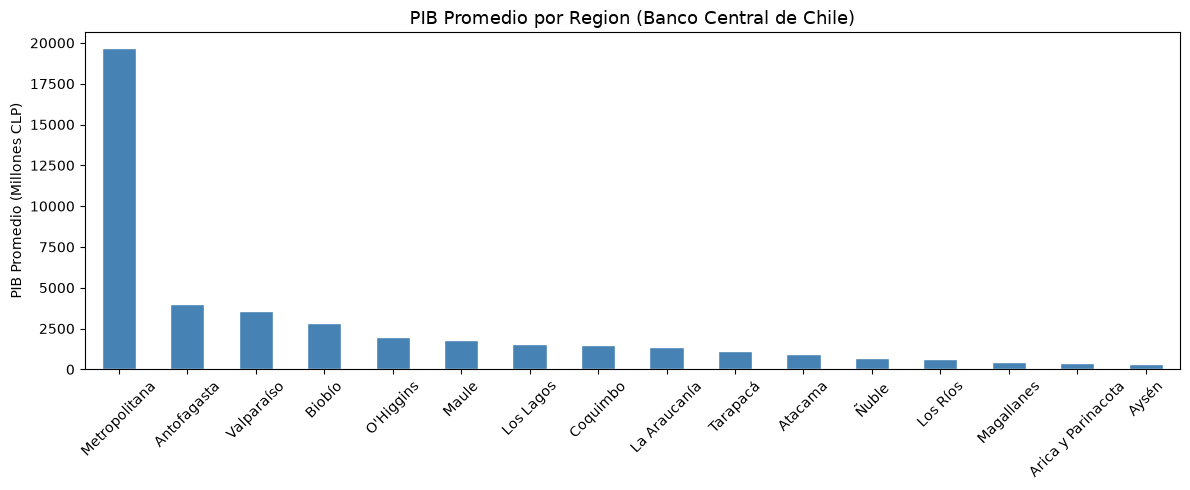

Regiones capturadas: 16


In [20]:
pib_region = df_pib.groupby("region")["pib_millones_clp"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
pib_region.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("PIB Promedio por Region (Banco Central de Chile)", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("PIB Promedio (Millones CLP)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
print(f"Regiones capturadas: {len(pib_region)}")

### 6.2 Distribucion de Costos Marginales

Analizamos la forma de la distribucion del precio de la energia para detectar outliers y sesgos.

C:\Users\Carlos\AppData\Local\Temp\ipykernel_50340\2002292704.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="region", y="costo_marginal_usd_mwh", ax=axes[1], palette="Set2", showfliers=False)


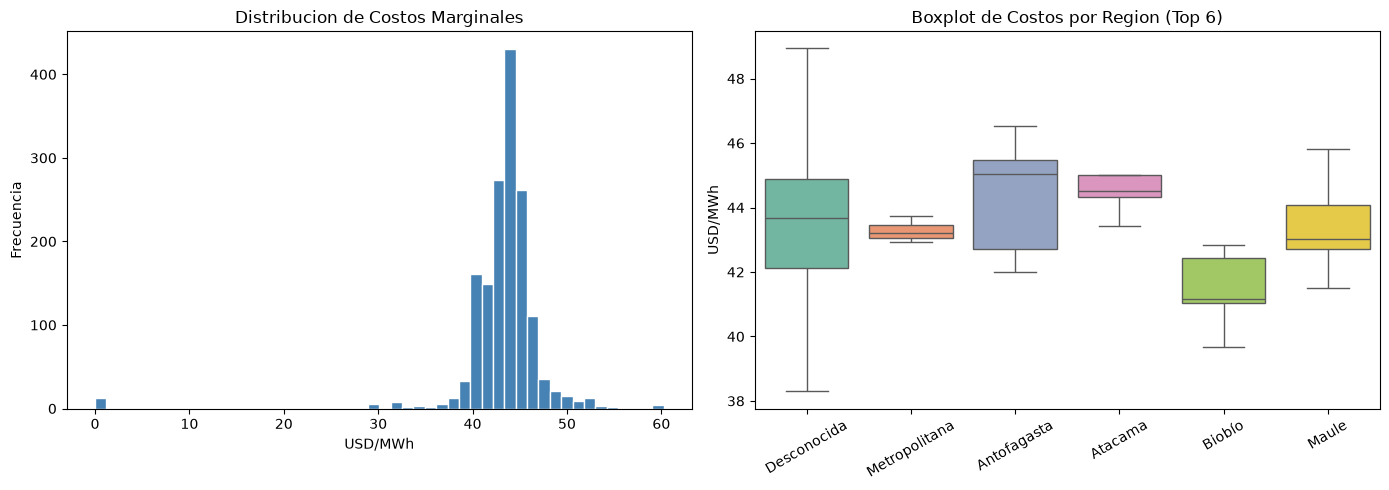

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_costos["costo_marginal_usd_mwh"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribucion de Costos Marginales")
axes[0].set_xlabel("USD/MWh")
axes[0].set_ylabel("Frecuencia")

# El join usa la columna "barra" de costos_marginales con "barra_codigo" de dim_barras
col_barra = "barra" if "barra" in df_costos.columns else "barra_codigo"
df_barras_join = df_barras.rename(columns={"barra_codigo": col_barra})
top_regiones = df_costos.merge(df_barras_join[[col_barra, "region"]], on=col_barra, how="left")
top6 = top_regiones["region"].value_counts().head(6).index
subset = top_regiones[top_regiones["region"].isin(top6)]
sns.boxplot(data=subset, x="region", y="costo_marginal_usd_mwh", ax=axes[1], palette="Set2", showfliers=False)
axes[1].set_title("Boxplot de Costos por Region (Top 6)")
axes[1].set_xlabel("")
axes[1].set_ylabel("USD/MWh")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### 6.3 Evolucion Temporal del Costo Marginal

Visualizamos como evoluciona el precio promedio de la energia a lo largo del tiempo.

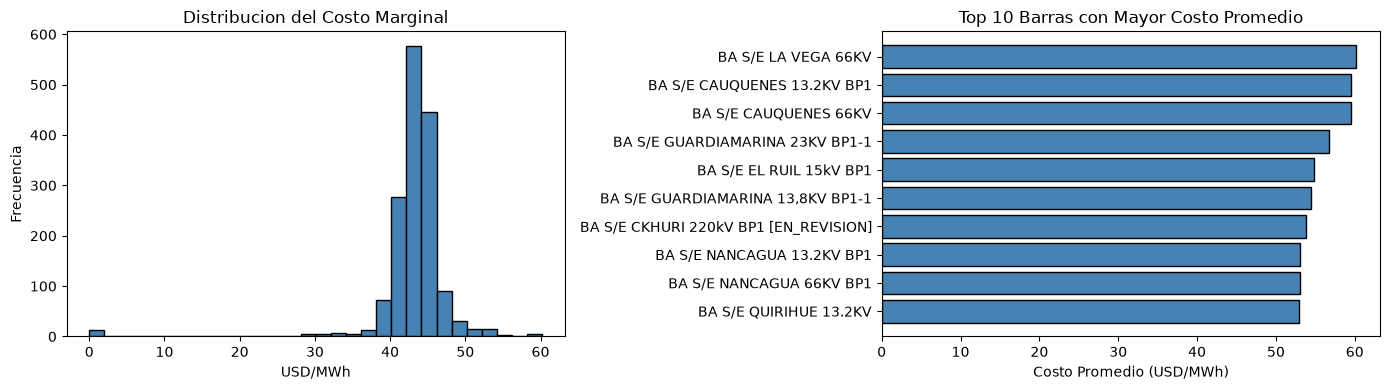

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Grafico 1: Distribucion de costos
axes[0].hist(df_costos["costo_marginal_usd_mwh"], bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Distribucion del Costo Marginal")
axes[0].set_xlabel("USD/MWh")
axes[0].set_ylabel("Frecuencia")

# Grafico 2: Top 10 barras con mayor costo promedio
top_barras = (
    df_costos.groupby("barra_nombre")["costo_marginal_usd_mwh"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
axes[1].barh(top_barras.index, top_barras.values, color="steelblue", edgecolor="black")
axes[1].set_title("Top 10 Barras con Mayor Costo Promedio")
axes[1].set_xlabel("Costo Promedio (USD/MWh)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
